In [1]:
import pandas as pd 
import numpy as ny 
import matplotlib.pyplot as plt 

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import pickle
import re


In [2]:
df= pd.read_csv("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/data/UpdatedResumeDataSet.csv")
df.head()

,Category,Resume
0,Data Science,Skills * Programming Languages: Python (pandas...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...
2,Data Science,"Areas of Interest Deep Learning, Control Syste..."
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab..."


In [3]:
df.shape

(962, 2)

In [4]:
df.columns

Index(['Category', 'Resume'], dtype='str')

In [5]:
df.isnull().sum()

Category    0
Resume      0
dtype: int64

In [6]:
df['Category'].value_counts()

Category
Java Developer               84
Testing                      70
DevOps Engineer              55
Python Developer             48
Web Designing                45
HR                           44
Hadoop                       42
Data Science                 40
Mechanical Engineer          40
Sales                        40
Operations Manager           40
ETL Developer                40
Blockchain                   40
Arts                         36
Database                     33
Health and fitness           30
Electrical Engineering       30
PMO                          30
Business Analyst             28
DotNet Developer             28
Automation Testing           26
Network Security Engineer    25
Civil Engineer               24
SAP Developer                24
Advocate                     20
Name: count, dtype: int64

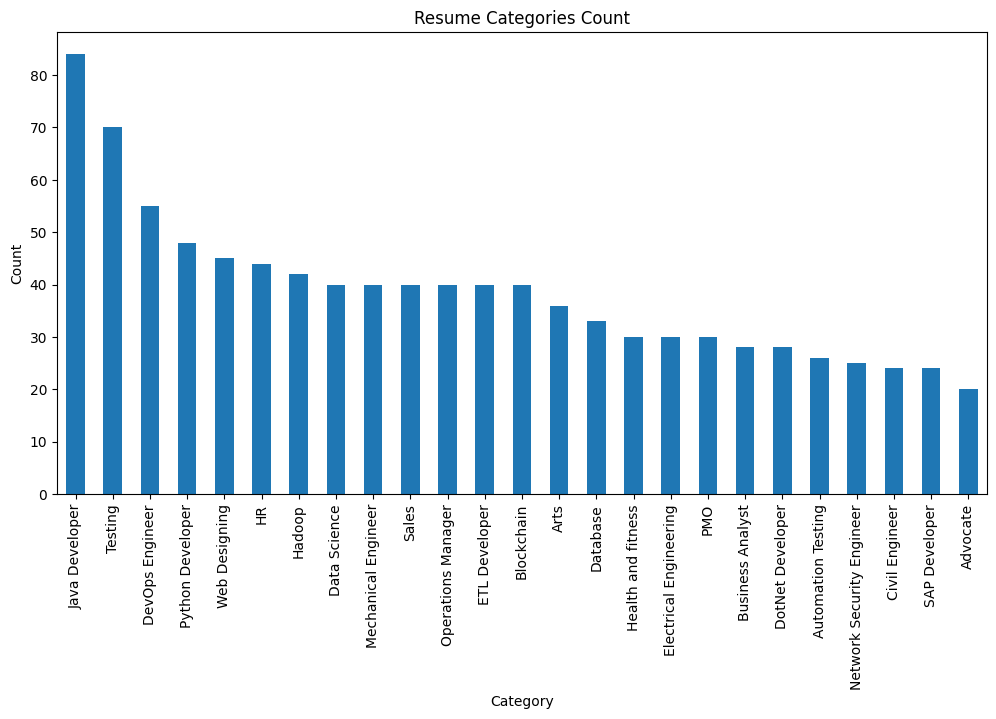

In [7]:
plt.figure(figsize=(12,6))
df['Category'].value_counts().plot(kind='bar')
plt.title("Resume Categories Count")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [8]:
def clean_resume(text):
          text = re.sub(r'http\S+', ' ', text)
          text = re.sub(r'RT|cc', ' ', text)
          text = re.sub(r'#\S+', ' ', text)
          text = re.sub(r'[^a-zA-Z\s]', ' ', text)
          text = re.sub(r'\s+', ' ', text)
          text = re.sub(r'@\S+', ' ', text)
          return text.lower().strip()

In [9]:
df['Cleaned_Resume'] = df['Resume'].apply(clean_resume)
df.head()

,Category,Resume,Cleaned_Resume
0,Data Science,Skills * Programming Languages: Python (pandas...,skills programming languages python pandas num...
1,Data Science,Education Details \r\nMay 2013 to May 2017 B.E...,education details may to may b e uit rgpv data...
2,Data Science,"Areas of Interest Deep Learning, Control Syste...",areas of interest deep learning control system...
3,Data Science,Skills â¢ R â¢ Python â¢ SAP HANA â¢ Table...,skills r python sap hana tableau sap hana sql ...
4,Data Science,"Education Details \r\n MCA YMCAUST, Faridab...",education details mca ymcaust faridabad haryan...


In [10]:
print("Original Resume:")
print(df['Resume'][0])

print("\nCleaned Resume:")
print(df['Cleaned_Resume'][0])

Original Resume:
Skills * Programming Languages: Python (pandas, numpy, scipy, scikit-learn, matplotlib), Sql, Java, JavaScript/JQuery. * Machine learning: Regression, SVM, NaÃ¯ve Bayes, KNN, Random Forest, Decision Trees, Boosting techniques, Cluster Analysis, Word Embedding, Sentiment Analysis, Natural Language processing, Dimensionality reduction, Topic Modelling (LDA, NMF), PCA & Neural Nets. * Database Visualizations: Mysql, SqlServer, Cassandra, Hbase, ElasticSearch D3.js, DC.js, Plotly, kibana, matplotlib, ggplot, Tableau. * Others: Regular Expression, HTML, CSS, Angular 6, Logstash, Kafka, Python Flask, Git, Docker, computer vision - Open CV and understanding of Deep learning.Education Details 

Data Science Assurance Associate 

Data Science Assurance Associate - Ernst & Young LLP
Skill Details 
JAVASCRIPT- Exprience - 24 months
jQuery- Exprience - 24 months
Python- Exprience - 24 monthsCompany Details 
company - Ernst & Young LLP
description - Fraud Investigations and Dispute

In [11]:
x = df['Cleaned_Resume']
y = df['Category']

In [12]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [13]:
print("Training data:", x_train.shape)
print("Testing data:", x_test.shape)

Training data: (769,)
Testing data: (193,)


In [14]:
tfidf = TfidfVectorizer(stop_words='english', max_features=5000)

x_train_tfidf = tfidf.fit_transform(x_train)
x_test_tfidf = tfidf.transform(x_test)

In [15]:
print(x_train_tfidf.shape)
print(x_test_tfidf.shape)

(769, 5000)
(193, 5000)


In [16]:
model = LogisticRegression(max_iter=1000)
model.fit(x_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [17]:
y_pred = model.predict(x_test_tfidf)

In [18]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9948186528497409


In [19]:
print(classification_report(y_test, y_pred))

                           precision    recall  f1-score   support

                 Advocate       1.00      1.00      1.00         3
                     Arts       1.00      1.00      1.00         6
       Automation Testing       1.00      1.00      1.00         5
               Blockchain       1.00      1.00      1.00         7
         Business Analyst       1.00      1.00      1.00         4
           Civil Engineer       1.00      1.00      1.00         9
             Data Science       1.00      1.00      1.00         5
                 Database       1.00      1.00      1.00         8
          DevOps Engineer       1.00      0.93      0.96        14
         DotNet Developer       1.00      1.00      1.00         5
            ETL Developer       1.00      1.00      1.00         7
   Electrical Engineering       1.00      1.00      1.00         6
                       HR       1.00      1.00      1.00        12
                   Hadoop       1.00      1.00      1.00     

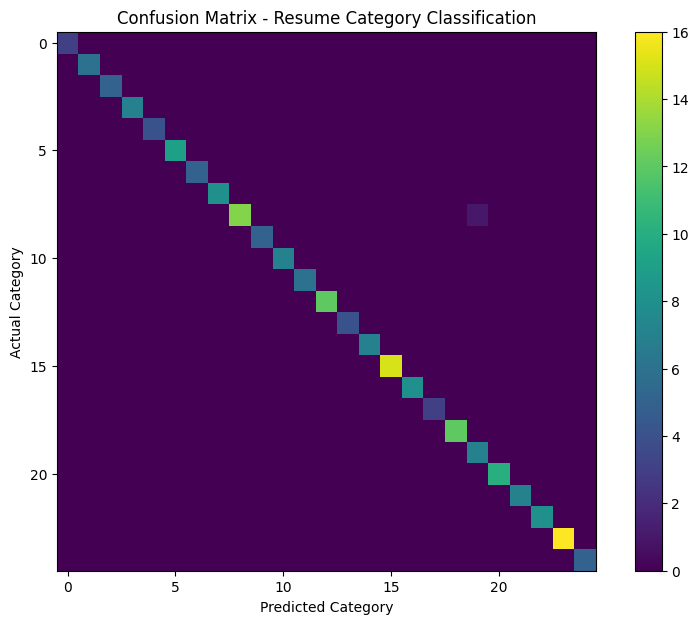

In [20]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10,7))
plt.imshow(cm)
plt.title("Confusion Matrix - Resume Category Classification")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.colorbar()
plt.show()

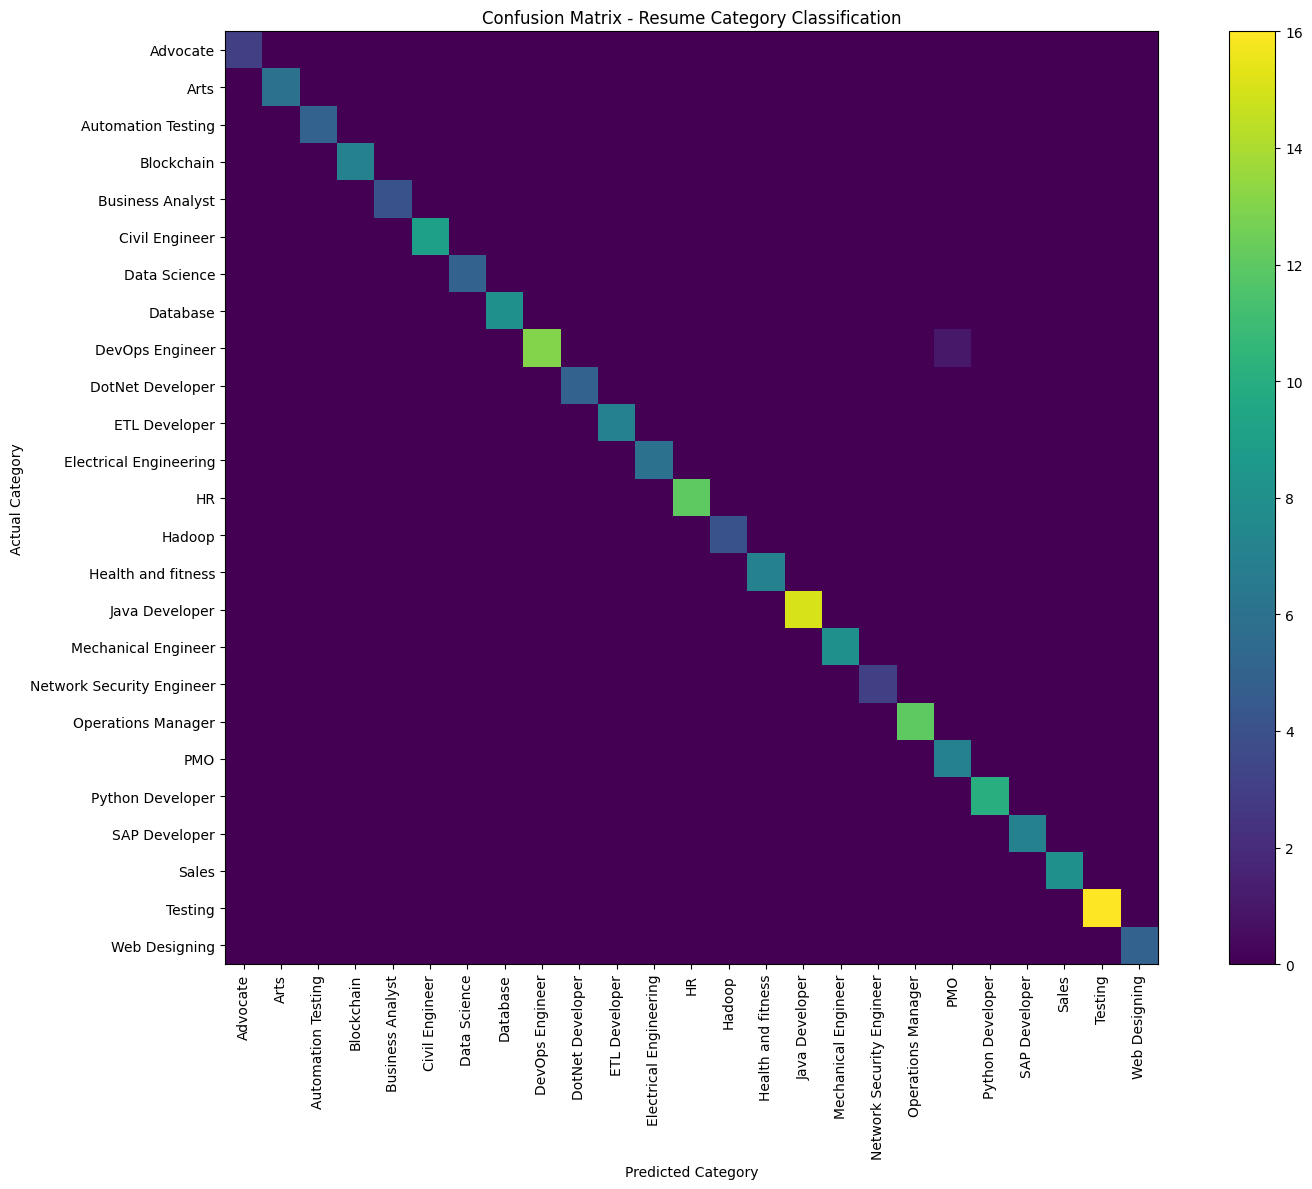

In [21]:
labels = sorted(y.unique())

cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(16,12))
plt.imshow(cm)
plt.title("Confusion Matrix - Resume Category Classification")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.xticks(ticks=range(len(labels)), labels=labels, rotation=90)
plt.yticks(ticks=range(len(labels)), labels=labels)
plt.colorbar()
plt.tight_layout()

plt.savefig("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/images/confusion_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

In [22]:
with open("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/models/resume_classifier_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/models/tfidf_vectorizer.pkl", "wb") as file:
          pickle.dump(tfidf,file)

In [23]:
import os

print(os.listdir("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/models"))
print(os.listdir("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/images"))

['tfidf_vectorizer.pkl', 'resume_classifier_model.pkl']
['confusion_matrix.png']


In [24]:
sample_resume = """
I have experience in Python, machine learning, pandas, numpy, scikit-learn, data visualization, SQL, statistics, predictive modeling and data analysis. """

cleaned_sample = clean_resume(sample_resume)
sample_tfidf = tfidf.transform([cleaned_sample])
prediction = model.predict(sample_tfidf)

print("Predicted Resume Category:", prediction[0])

Predicted Resume Category: Data Science


In [25]:
with open("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/models/resume_classifier_model.pkl", "wb") as file:
    pickle.dump(model, file)

with open("/Users/vikirthan17/Documents/Project_04_AI_Resume_Analyzer/models/tfidf_vectorizer.pkl", "wb") as file:
            pickle.dump(tfidf, file)